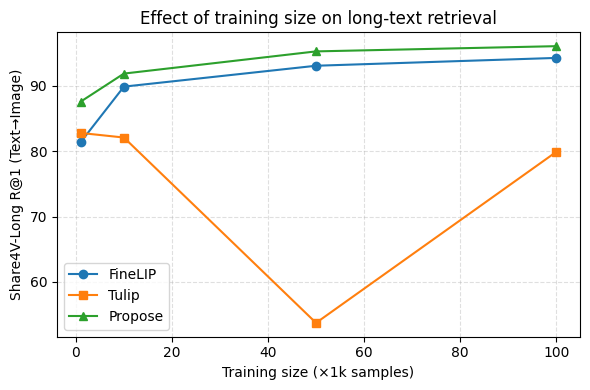

In [4]:
import matplotlib.pyplot as plt

train_sizes = [1, 10, 50, 100]  # x axis (k)
fine_r1 = [81.4, 89.9, 93.1, 94.3]
tulip_r1 = [82.8, 82.1, 53.7, 79.9]
prop_r1 = [87.6, 91.9, 95.3, 96.1]

plt.figure(figsize=(6,4))
plt.plot(train_sizes, fine_r1, '-o', label='FineLIP')
plt.plot(train_sizes, tulip_r1, '-s', label='Tulip')
plt.plot(train_sizes, prop_r1, '-^', label='Propose')

plt.xlabel("Training size (×1k samples)")
plt.ylabel("Share4V-Long R@1 (Text→Image)")
plt.title("Effect of training size on long-text retrieval")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


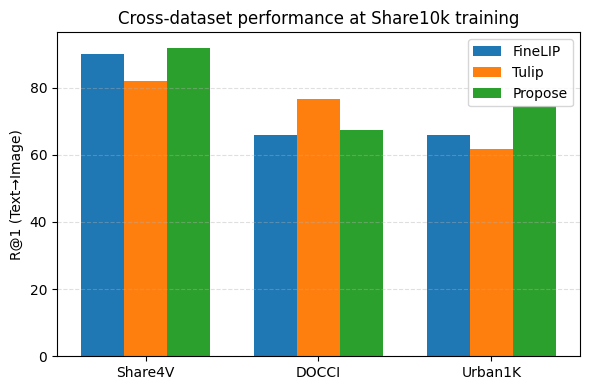

In [2]:
import numpy as np
import matplotlib.pyplot as plt

methods = ["FineLIP", "Tulip", "Propose"]
datasets = ["Share4V", "DOCCI", "Urban1K"]

# R@1 for Share10k
data = np.array([
    [89.9, 65.88, 65.8],  # FineLIP
    [82.1, 76.5, 61.6],   # Tulip
    [91.9, 67.39, 74.6]   # Propose
]).T  # shape: (datasets, methods)

x = np.arange(len(datasets))
bar_width = 0.25

plt.figure(figsize=(6,4))
for i, method in enumerate(methods):
    plt.bar(x + i*bar_width, data[:, i], width=bar_width, label=method)

plt.xticks(x + bar_width, datasets)
plt.ylabel("R@1 (Text→Image)")
plt.title("Cross-dataset performance at Share10k training")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


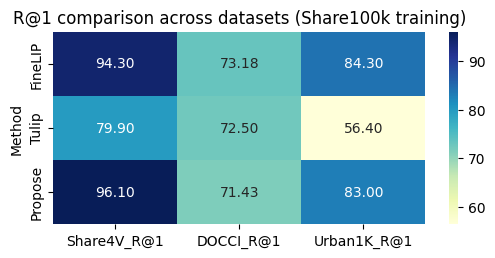

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "Method": ["FineLIP", "Tulip", "Propose"],
    "Share4V_R@1": [94.3, 79.9, 96.1],
    "DOCCI_R@1": [73.18, 72.5, 71.43],
    "Urban1K_R@1": [84.3, 56.4, 83.0]
}
df = pd.DataFrame(data).set_index("Method")

plt.figure(figsize=(6,2.5))
sns.heatmap(df, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("R@1 comparison across datasets (Share100k training)")
plt.show()


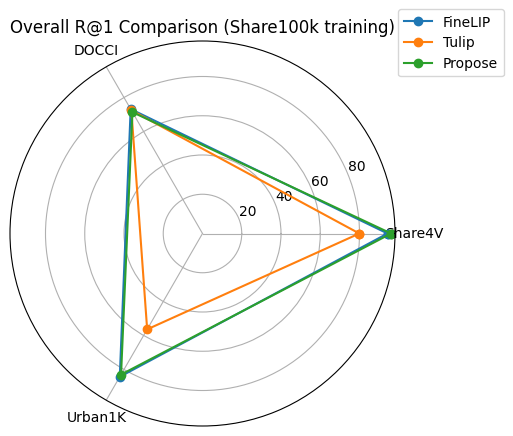

In [2]:
import numpy as np
import matplotlib.pyplot as plt

labels = ["Share4V", "DOCCI", "Urban1K"]
fine = [94.3, 73.2, 84.3]
tulip = [79.9, 72.5, 56.4]
prop = [96.1, 71.4, 83.0]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]
labels += labels[:1]

def plot_radar(values, label):
    values += values[:1]
    plt.polar(angles, values, '-o', label=label)

plt.figure(figsize=(5,5))
plot_radar(fine, "FineLIP")
plot_radar(tulip, "Tulip")
plot_radar(prop, "Propose")
plt.xticks(angles[:-1], labels[:-1])
plt.title("Overall R@1 Comparison (Share100k training)")
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()


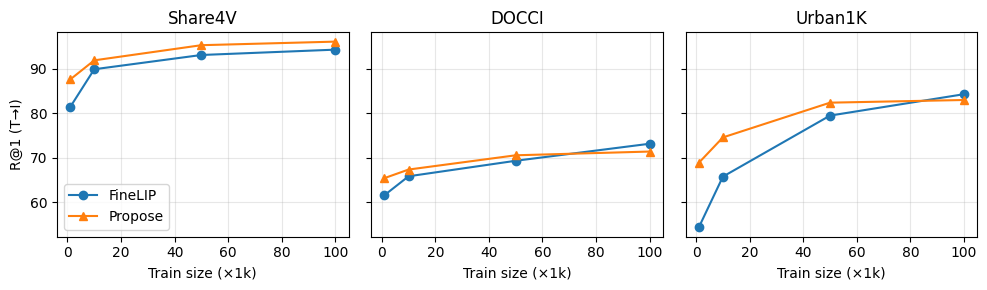

In [5]:
fig, axes = plt.subplots(1,3, figsize=(10,3), sharey=True)
datasets = ["Share4V", "DOCCI", "Urban1K"]
fine = [[81.4,89.9,93.1,94.3], [61.64,65.88,69.36,73.18], [54.4,65.8,79.5,84.3]]
prop = [[87.6,91.9,95.3,96.1], [65.47,67.39,70.59,71.43], [68.9,74.6,82.4,83.0]]

for ax, name, y1, y2 in zip(axes, datasets, fine, prop):
    ax.plot(train_sizes, y1, '-o', label='FineLIP')
    ax.plot(train_sizes, y2, '-^', label='Propose')
    ax.set_title(name)
    ax.set_xlabel("Train size (×1k)")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("R@1 (T→I)")
axes[0].legend()
plt.tight_layout()
plt.show()


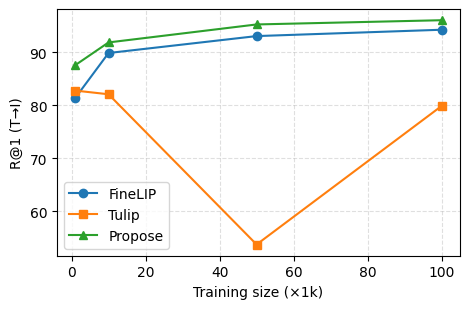

In [6]:
import matplotlib.pyplot as plt

sizes = [1, 10, 50, 100]  # ×1k
fine = [81.4, 89.9, 93.1, 94.3]   # ví dụ: Share4V T→I R@1
tulip = [82.8, 82.1, 53.7, 79.9]
prop  = [87.6, 91.9, 95.3, 96.1]

plt.figure(figsize=(4.8,3.2))
plt.plot(sizes, fine,  '-o', label='FineLIP')
plt.plot(sizes, tulip, '-s', label='Tulip')
plt.plot(sizes, prop,  '-^', label='Propose')
plt.xlabel('Training size (×1k)'); plt.ylabel('R@1 (T→I)')
plt.grid(True, ls='--', alpha=.4); plt.legend(); plt.tight_layout(); plt.show()


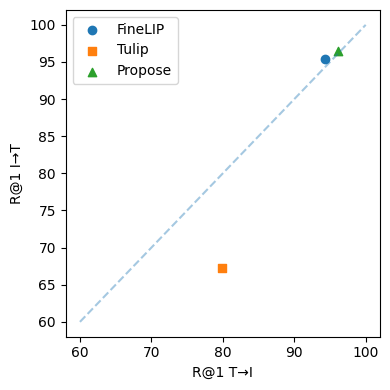

In [7]:
import matplotlib.pyplot as plt

# ví dụ Share100k
fine = (94.3, 95.4); tulip = (79.9, 67.3); prop = (96.1, 96.5)
plt.figure(figsize=(4,4))
plt.scatter(fine[0], fine[1], marker='o', label='FineLIP')
plt.scatter(tulip[0], tulip[1], marker='s', label='Tulip')
plt.scatter(prop[0],  prop[1],  marker='^', label='Propose')
plt.plot([60,100],[60,100], ls='--', alpha=.4)  # đường cân bằng
plt.xlabel('R@1 T→I'); plt.ylabel('R@1 I→T'); plt.legend(); plt.tight_layout(); plt.show()


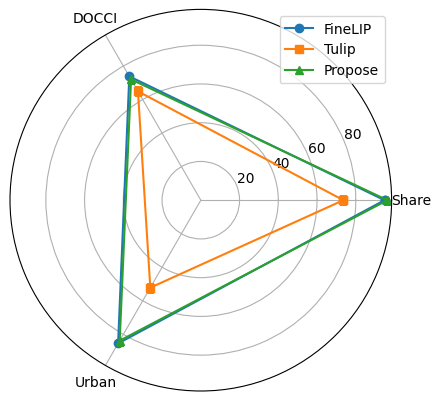

In [8]:
import numpy as np, matplotlib.pyplot as plt
labels = ['Share','DOCCI','Urban']
fine = [ (94.3+95.4)/2, (73.18+74.48)/2, (84.3+86.5)/2 ]
tulip= [ (79.9+67.3)/2, (72.5+57.3)/2,  (56.4+47.9)/2 ]
prop = [ (96.1+96.5)/2, (71.43+72.61)/2,(83.0+84.5)/2 ]

angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(4.5,4.5))
for vals, name, mk in [(fine,'FineLIP','o'),(tulip,'Tulip','s'),(prop,'Propose','^')]:
    v = vals + vals[:1]
    plt.polar(angles, v, marker=mk, label=name)
plt.xticks(angles[:-1], labels); plt.legend(loc='upper right'); plt.tight_layout(); plt.show()


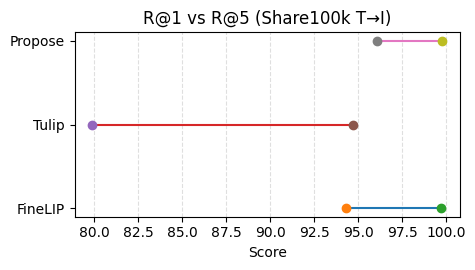

In [9]:
import matplotlib.pyplot as plt

methods = ['FineLIP','Tulip','Propose']
r1 = [94.3, 79.9, 96.1]   # Share100k T→I
r5 = [99.7, 94.7, 99.8]

y = range(len(methods))
plt.figure(figsize=(4.8,2.8))
for i, m in enumerate(methods):
    plt.plot([r1[i], r5[i]], [i, i], '-')
    plt.plot(r1[i], i, 'o'); plt.plot(r5[i], i, 'o')
plt.yticks(y, methods); plt.xlabel('Score'); plt.title('R@1 vs R@5 (Share100k T→I)')
plt.grid(axis='x', ls='--', alpha=.4); plt.tight_layout(); plt.show()


# Artpedia and OpenV1 statistic

File: gt_train.csv
Samples (ALL): 22,040
Sentence per caption -> min: 1, max: 46, avg: 5.73
Top 10 most common (sentences -> #captions):
   5 -> 7,151
   4 -> 5,912
   6 -> 3,209
   3 -> 1,261
   7 -> 1,083
  10 -> 539
  11 -> 533
   8 -> 476
   9 -> 465
  12 -> 426


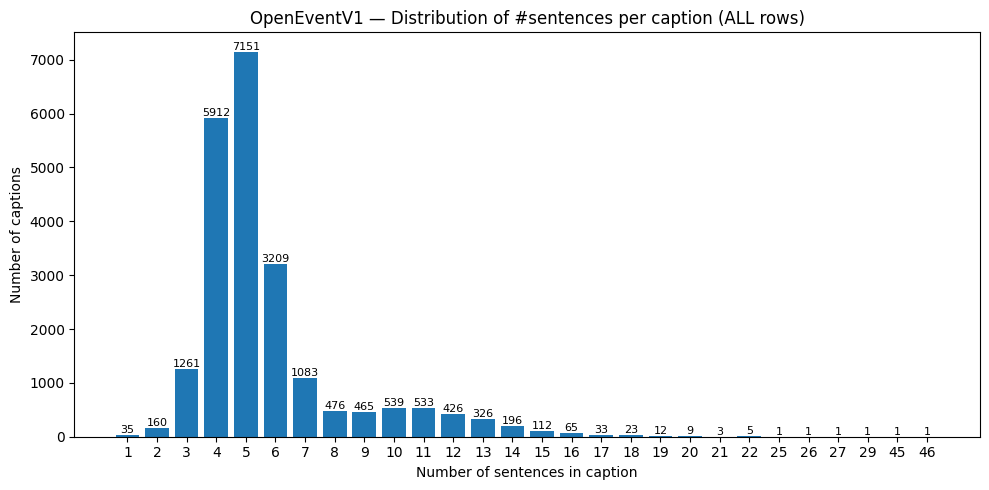

In [1]:
# %% OpenEventV1 | Sentence-count statistics on ALL rows + bar chart
import csv, re
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

# ====== Config ======
ROOT_DIR = "/home/ubuntu/shared/OpenEvenv1/train/Train Set"  # <-- CHỈNH LẠI
CSV_NAME = "gt_train.csv"
MAX_ITEMS = None  # đặt số nguyên để giới hạn nhanh; None = dùng hết

# ====== Helpers ======
def normalize_text(s: str) -> str:
    s = (s or "").replace("\r\n", "\n").replace("\t", " ").replace("\n", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s

def split_sentences(text: str):
    if not text:
        return []
    text = text.replace("…", "… ")
    parts = re.split(r"(?<=[\.\!\?。！？…])\s+(?=[^\s])|(?<=[\.\!\?。！？…])$", text)
    sents = [re.sub(r"\s+", " ", p).strip() for p in parts if p and p.strip()]
    return sents

def read_all_rows(csv_path: Path):
    assert csv_path.is_file(), f"Không tìm thấy CSV: {csv_path}"
    rows = []
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        for r in reader:
            rows.append({"caption": r.get("caption", "")})
    return rows

def count_sentence_per_caption(rows, max_items=None):
    counts = Counter()
    total = 0
    it = rows if (max_items is None) else rows[:max_items]
    for item in it:
        cap = normalize_text(item.get("caption", ""))
        sents = split_sentences(cap)
        n = len(sents)
        if n == 0 and cap:
            n = 1
        counts[n] += 1
        total += 1
    return counts, total

def summarize_and_plot(counts: Counter, total_items: int, csv_name: str):
    if total_items == 0:
        raise ValueError("CSV không có hàng hợp lệ.")
    min_c = min(counts.keys())
    max_c = max(counts.keys())
    avg = sum(k * v for k, v in counts.items()) / total_items

    print(f"File: {csv_name}")
    print(f"Samples (ALL): {total_items:,}")
    print(f"Sentence per caption -> min: {min_c}, max: {max_c}, avg: {avg:.2f}")
    print("Top 10 most common (sentences -> #captions):")
    for k, v in counts.most_common(10):
        print(f"  {k:>2} -> {v:,}")

    xs = sorted(counts.keys())
    ys = [counts[x] for x in xs]
    plt.figure(figsize=(10, 5))
    plt.bar([str(x) for x in xs], ys)
    plt.title("OpenEventV1 — Distribution of #sentences per caption (ALL rows)")
    plt.xlabel("Number of sentences in caption")
    plt.ylabel("Number of captions")
    if len(xs) <= 40:
        for x, y in zip(xs, ys):
            plt.text(str(x), y, f"{y}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

# ====== Run (ALL rows) ======
csv_path = Path(ROOT_DIR) / CSV_NAME
rows_all = read_all_rows(csv_path)
counts, total = count_sentence_per_caption(rows_all, MAX_ITEMS)
summarize_and_plot(counts, total, csv_path.name)


File: artpedia_filtered.json
Samples (ALL): 2,821
Sentence per LONG caption -> min: 1, max: 32, avg: 3.53
Top 10 most common (sentences -> #captions):
   1 -> 983
   2 -> 568
   3 -> 325
   4 -> 234
   5 -> 153
   6 -> 135
   7 -> 103
   8 -> 75
   9 -> 74
  10 -> 41


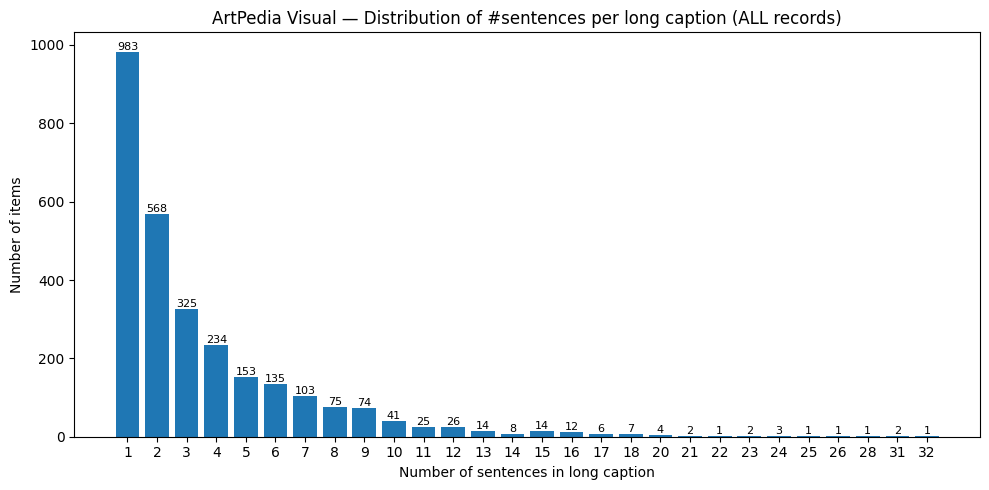

In [3]:
# %% ArtPedia | Sentence-count statistics on long captions + bar chart
import json, re
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

# ====== Config ======
ART_ROOT  = "/home/ubuntu/shared/ARO/artpedia"   # <-- CHỈNH LẠI NẾU CẦN
JSON_NAME = "artpedia_filtered.json"
MAX_ITEMS = None  # đặt số nguyên để giới hạn nhanh; None = dùng hết

# ====== Helpers for ArtPedia loading & caption building ======
def _load_records(json_path: Path):
    """
    Đọc JSON ArtPedia và trả về list[dict].
    Hỗ trợ:
      1) [ {...}, {...} ]
      2) { "data": [ {...} ] }
      3) { "2": {...}, "3": {...} }  (dict-of-dicts)
    """
    with open(json_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    if isinstance(raw, list):
        return [r for r in raw if isinstance(r, dict)]

    if isinstance(raw, dict) and "data" in raw and isinstance(raw["data"], list):
        return [r for r in raw["data"] if isinstance(r, dict)]

    if isinstance(raw, dict):
        out = []
        for k, v in raw.items():
            if isinstance(v, dict):
                if "id" not in v:
                    vv = v.copy()
                    vv["id"] = k
                    out.append(vv)
                else:
                    out.append(v)
        if out:
            return out

    raise ValueError(f"Unrecognized JSON format at '{json_path}'")


def _make_caption_from_art(item: dict, include_title: bool = True, text_mode: str = "visual") -> str:
    """
    Tạo caption 'dài' cho ArtPedia từ visual/contextual sentences.
    Giữ đúng logic bạn dùng trong eval_artpedia_retrieval (chỉ khác default text_mode='visual').
    """
    visual = [(s or "").replace("\n", " ").strip()
              for s in (item.get("visual_sentences") or [])
              if (s or "").strip()]
    context = [(s or "").replace("\n", " ").strip()
               for s in (item.get("contextual_sentences") or [])
               if (s or "").strip()]

    if text_mode == "visual":
        parts = visual
    elif text_mode == "contextual":
        parts = context
    else:
        parts = visual + context

    if include_title:
        t = (item.get("title") or "").strip()
        if t:
            parts = [t + "."] + parts

    cap = " ".join(parts).strip()
    cap = re.sub(r"\s+", " ", cap)
    return cap


def normalize_text(s: str) -> str:
    s = (s or "").replace("\r\n", "\n").replace("\t", " ").replace("\n", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s


def split_sentences(text: str):
    """
    Tách câu đơn giản theo . ! ? ; : và dấu câu tương tự.
    """
    if not text:
        return []
    text = text.replace("…", "… ")
    parts = re.split(
        r"(?<=[\.\!\?;:。！？…])\s+(?=[^\s])|(?<=[\.\!\?;:。！？…])$",
        text,
    )
    sents = [re.sub(r"\s+", " ", p).strip() for p in parts if p and p.strip()]
    return sents


def count_sentence_per_caption(records, max_items=None):
    counts = Counter()
    total = 0
    it = records if (max_items is None) else records[:max_items]
    for item in it:
        cap_long = _make_caption_from_art(item, include_title=False, text_mode="visual")
        cap_long = normalize_text(cap_long)
        sents = split_sentences(cap_long)
        n = len(sents)
        if n == 0 and cap_long:
            n = 1
        counts[n] += 1
        total += 1
    return counts, total


def summarize_and_plot(counts: Counter, total_items: int, json_name: str):
    if total_items == 0:
        raise ValueError("Không có record hợp lệ trong ArtPedia JSON.")
    min_c = min(counts.keys())
    max_c = max(counts.keys())
    avg = sum(k * v for k, v in counts.items()) / total_items

    print(f"File: {json_name}")
    print(f"Samples (ALL): {total_items:,}")
    print(f"Sentence per LONG caption -> min: {min_c}, max: {max_c}, avg: {avg:.2f}")
    print("Top 10 most common (sentences -> #captions):")
    for k, v in counts.most_common(10):
        print(f"  {k:>2} -> {v:,}")

    xs = sorted(counts.keys())
    ys = [counts[x] for x in xs]
    plt.figure(figsize=(10, 5))
    plt.bar([str(x) for x in xs], ys)
    plt.title("ArtPedia Visual — Distribution of #sentences per long caption (ALL records)")
    plt.xlabel("Number of sentences in long caption")
    plt.ylabel("Number of items")
    if len(xs) <= 40:
        for x, y in zip(xs, ys):
            plt.text(str(x), y, f"{y}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()


# ====== Run (ALL records) ======
json_path = Path(ART_ROOT) / JSON_NAME
records = _load_records(json_path)
counts, total = count_sentence_per_caption(records, MAX_ITEMS)
summarize_and_plot(counts, total, json_path.name)


File: artpedia_filtered.json
Samples (ALL): 2,821
Sentence per LONG caption -> min: 0, max: 63, avg: 7.34
Top 10 most common (sentences -> #captions):
   4 -> 334
   2 -> 328
   3 -> 323
   5 -> 256
   6 -> 194
   1 -> 192
   7 -> 185
   8 -> 147
   9 -> 122
  12 -> 90


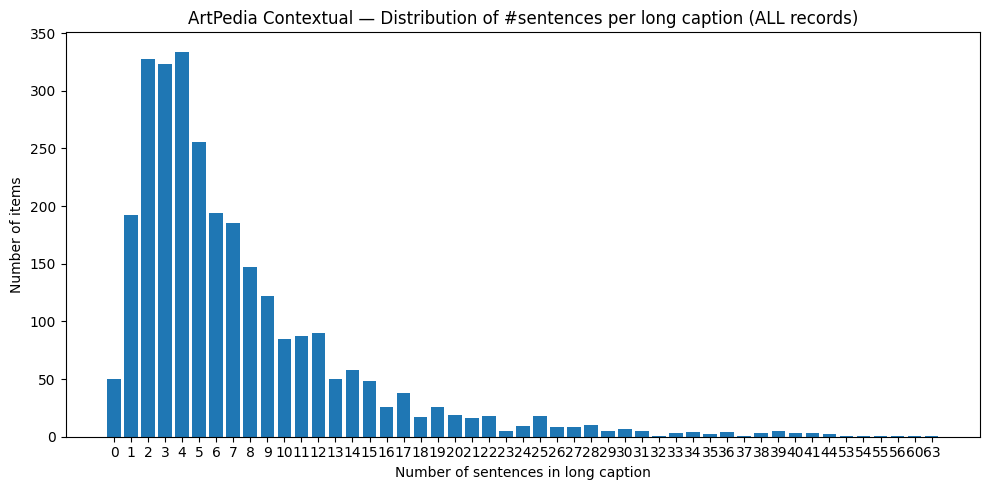

In [4]:
# %% ArtPedia | Sentence-count statistics on long captions + bar chart
import json, re
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

# ====== Config ======
ART_ROOT  = "/home/ubuntu/shared/ARO/artpedia"   # <-- CHỈNH LẠI NẾU CẦN
JSON_NAME = "artpedia_filtered.json"
MAX_ITEMS = None  # đặt số nguyên để giới hạn nhanh; None = dùng hết

# ====== Helpers for ArtPedia loading & caption building ======
def _load_records(json_path: Path):
    """
    Đọc JSON ArtPedia và trả về list[dict].
    Hỗ trợ:
      1) [ {...}, {...} ]
      2) { "data": [ {...} ] }
      3) { "2": {...}, "3": {...} }  (dict-of-dicts)
    """
    with open(json_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    if isinstance(raw, list):
        return [r for r in raw if isinstance(r, dict)]

    if isinstance(raw, dict) and "data" in raw and isinstance(raw["data"], list):
        return [r for r in raw["data"] if isinstance(r, dict)]

    if isinstance(raw, dict):
        out = []
        for k, v in raw.items():
            if isinstance(v, dict):
                if "id" not in v:
                    vv = v.copy()
                    vv["id"] = k
                    out.append(vv)
                else:
                    out.append(v)
        if out:
            return out

    raise ValueError(f"Unrecognized JSON format at '{json_path}'")


def _make_caption_from_art(item: dict, include_title: bool = True, text_mode: str = "visual") -> str:
    """
    Tạo caption 'dài' cho ArtPedia từ visual/contextual sentences.
    Giữ đúng logic bạn dùng trong eval_artpedia_retrieval (chỉ khác default text_mode='visual').
    """
    visual = [(s or "").replace("\n", " ").strip()
              for s in (item.get("visual_sentences") or [])
              if (s or "").strip()]
    context = [(s or "").replace("\n", " ").strip()
               for s in (item.get("contextual_sentences") or [])
               if (s or "").strip()]

    if text_mode == "visual":
        parts = visual
    elif text_mode == "contextual":
        parts = context
    else:
        parts = visual + context

    if include_title:
        t = (item.get("title") or "").strip()
        if t:
            parts = [t + "."] + parts

    cap = " ".join(parts).strip()
    cap = re.sub(r"\s+", " ", cap)
    return cap


def normalize_text(s: str) -> str:
    s = (s or "").replace("\r\n", "\n").replace("\t", " ").replace("\n", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s


def split_sentences(text: str):
    """
    Tách câu đơn giản theo . ! ? ; : và dấu câu tương tự.
    """
    if not text:
        return []
    text = text.replace("…", "… ")
    parts = re.split(
        r"(?<=[\.\!\?;:。！？…])\s+(?=[^\s])|(?<=[\.\!\?;:。！？…])$",
        text,
    )
    sents = [re.sub(r"\s+", " ", p).strip() for p in parts if p and p.strip()]
    return sents


def count_sentence_per_caption(records, max_items=None):
    counts = Counter()
    total = 0
    it = records if (max_items is None) else records[:max_items]
    for item in it:
        cap_long = _make_caption_from_art(item, include_title=False, text_mode="contextual")
        cap_long = normalize_text(cap_long)
        sents = split_sentences(cap_long)
        n = len(sents)
        if n == 0 and cap_long:
            n = 1
        counts[n] += 1
        total += 1
    return counts, total


def summarize_and_plot(counts: Counter, total_items: int, json_name: str):
    if total_items == 0:
        raise ValueError("Không có record hợp lệ trong ArtPedia JSON.")
    min_c = min(counts.keys())
    max_c = max(counts.keys())
    avg = sum(k * v for k, v in counts.items()) / total_items

    print(f"File: {json_name}")
    print(f"Samples (ALL): {total_items:,}")
    print(f"Sentence per LONG caption -> min: {min_c}, max: {max_c}, avg: {avg:.2f}")
    print("Top 10 most common (sentences -> #captions):")
    for k, v in counts.most_common(10):
        print(f"  {k:>2} -> {v:,}")

    xs = sorted(counts.keys())
    ys = [counts[x] for x in xs]
    plt.figure(figsize=(10, 5))
    plt.bar([str(x) for x in xs], ys)
    plt.title("ArtPedia Contextual — Distribution of #sentences per long caption (ALL records)")
    plt.xlabel("Number of sentences in long caption")
    plt.ylabel("Number of items")
    if len(xs) <= 40:
        for x, y in zip(xs, ys):
            plt.text(str(x), y, f"{y}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()


# ====== Run (ALL records) ======
json_path = Path(ART_ROOT) / JSON_NAME
records = _load_records(json_path)
counts, total = count_sentence_per_caption(records, MAX_ITEMS)
summarize_and_plot(counts, total, json_path.name)


# making the graphs

Average R@1 per #subcaptions: [69.47595000000001, 69.53264999999999, 69.6234, 69.32849999999999, 69.2604]


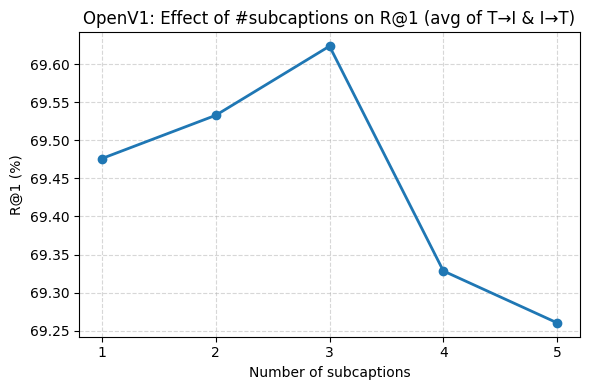

In [1]:
import matplotlib.pyplot as plt

# Number of subcaptions (OpenV1)
num_subcaps = [1, 2, 3, 4, 5]

# R@1 (%) for OpenV1
# "Full Text → Image @ 1" (T→I)
t2i_r1 = [
    68.2622,  # 1 sentence only
    68.4664,  # 2
    68.3757,  # 3
    67.9220,  # 4
    68.2849,  # 5
]

# "Image → Full Text @ 1" (I→T)
i2t_r1 = [
    70.6897,  # 1 sentence only
    70.5989,  # 2
    70.8711,  # 3
    70.7350,  # 4
    70.2359,  # 5
]

# Average of T→I and I→T R@1
avg_r1 = [(t + i) / 2.0 for t, i in zip(t2i_r1, i2t_r1)]

print("Average R@1 per #subcaptions:", avg_r1)

plt.figure(figsize=(6, 4))
plt.plot(num_subcaps, avg_r1, marker="o", linewidth=2)

plt.title("OpenV1: Effect of #subcaptions on R@1 (avg of T→I & I→T)")
plt.xlabel("Number of subcaptions")
plt.ylabel("R@1 (%)")
plt.xticks(num_subcaps)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


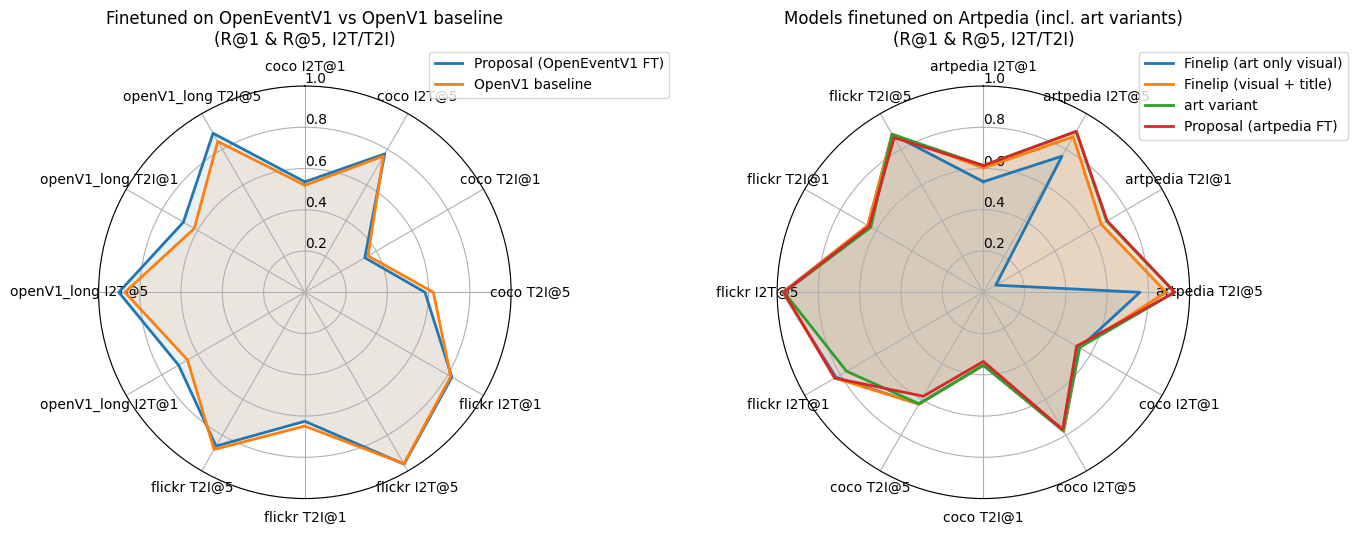

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def make_radar(ax, categories, model_dict, title):
    n_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))

    ax.set_theta_offset(np.pi / 2.0)
    ax.set_theta_direction(-1)

    ax.set_thetagrids(np.degrees(angles[:-1]), categories)
    ax.set_ylim(0.0, 1.0)
    ax.set_rlabel_position(0)

    for label, vals in model_dict.items():
        data = np.array(vals)
        data = np.concatenate((data, [data[0]]))
        ax.plot(angles, data, linewidth=2, label=label)
        ax.fill(angles, data, alpha=0.1)

    ax.set_title(title, y=1.08)
    ax.grid(True)


def main():
    # =========================
    # 1) OpenEventV1 finetune
    # =========================
    categories_event = [
        "coco I2T@1", "coco I2T@5", "coco T2I@1", "coco T2I@5",
        "flickr I2T@1", "flickr I2T@5", "flickr T2I@1", "flickr T2I@5",
        "openV1_long I2T@1", "openV1_long I2T@5", "openV1_long T2I@1", "openV1_long T2I@5",
    ]

    # Proposal (finetuned on OpenEventV1) — converted from %
    proposal_openevent = [
        # coco
        0.5356, 0.7748, 0.3356, 0.5825,
        # flickr
        0.8230, 0.9620, 0.6254, 0.8610,
        # openV1_long
        0.7067, 0.9018, 0.6799, 0.8902,
    ]

    # OpenV1 baseline
    baseline_openv1 = [
        # coco
        0.5186, 0.7628, 0.3536, 0.6233,
        # flickr
        0.8170, 0.9600, 0.6488, 0.8802,
        # openV1_long (test mean)
        0.6565, 0.8723, 0.6189, 0.8444,
    ]

    models_event = {
        "Proposal (OpenEventV1 FT)": proposal_openevent,
        "OpenV1 baseline": baseline_openv1,
    }

    # =========================
    # 2) Artpedia finetune + art variants
    # =========================
    categories_art = [
        "artpedia I2T@1", "artpedia I2T@5", "artpedia T2I@1", "artpedia T2I@5",
        "coco I2T@1", "coco I2T@5", "coco T2I@1", "coco T2I@5",
        "flickr I2T@1", "flickr I2T@5", "flickr T2I@1", "flickr T2I@5",
    ]

    # Finelip - Art only visual
    finelip_art_only = [
        # artpedia
        0.5361, 0.7620, 0.0693, 0.7590,
        # coco
        0.5388, 0.7782, 0.3544, 0.6264,
        # flickr
        0.8250, 0.9730, 0.6464, 0.8850,
    ]

    # Finelip - Art visual + title
    finelip_art_title = [
        # artpedia
        0.6024, 0.8705, 0.6596, 0.8855,
        # coco
        0.5362, 0.7766, 0.3526, 0.6254,
        # flickr
        0.8320, 0.9700, 0.6476, 0.8854,
    ]

    # "art" variant (global)
    art_variant = [
        # artpedia
        0.6145, 0.9006, 0.6898, 0.9277,
        # coco
        0.5366, 0.7724, 0.3530, 0.6238,
        # flickr
        0.7660, 0.9660, 0.6302, 0.8842,
    ]

    # Proposal (artpedia finetune)
    proposal_artpedia = [
        # artpedia
        0.6145, 0.9006, 0.6928, 0.9277,
        # coco
        0.5220, 0.7678, 0.3353, 0.5819,
        # flickr
        0.8320, 0.9670, 0.6396, 0.8654,
    ]

    models_art = {
        "Finelip (art only visual)": finelip_art_only,
        "Finelip (visual + title)": finelip_art_title,
        "art variant": art_variant,
        "Proposal (artpedia FT)": proposal_artpedia,
    }

    # =========================
    # Combined figure (2 radars horizontally)
    # =========================
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(14, 7), subplot_kw=dict(polar=True)
    )

    make_radar(
        ax1,
        categories_event,
        models_event,
        "Finetuned on OpenEventV1 vs OpenV1 baseline\n(R@1 & R@5, I2T/T2I)"
    )
    ax1.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1))

    make_radar(
        ax2,
        categories_art,
        models_art,
        "Models finetuned on Artpedia (incl. art variants)\n(R@1 & R@5, I2T/T2I)"
    )
    ax2.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1))

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


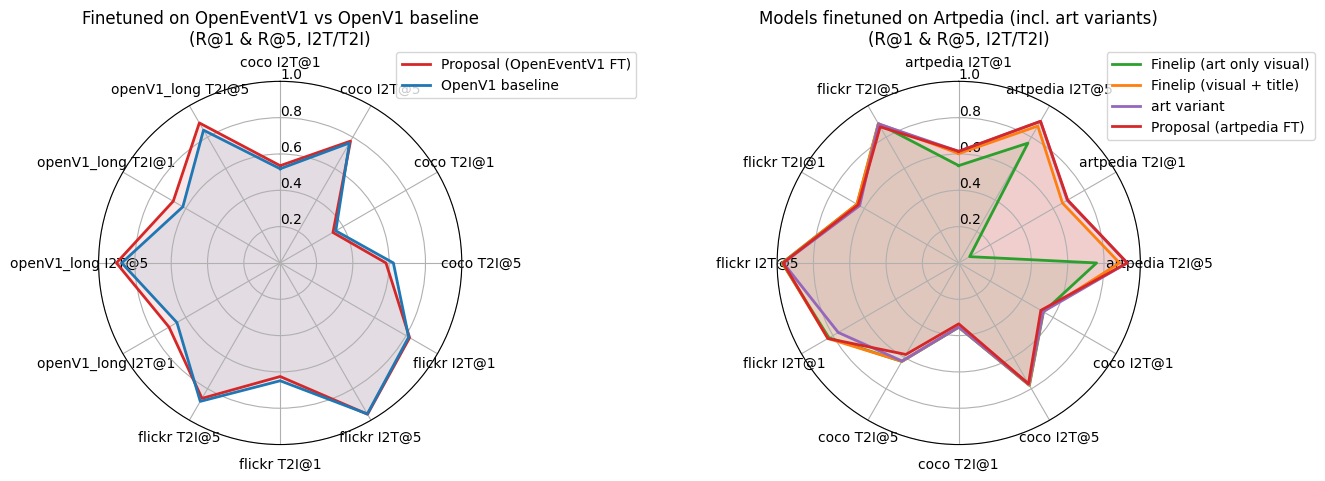

In [6]:
import numpy as np
import matplotlib.pyplot as plt


def make_radar(ax, categories, model_dict, title, color_map=None):
    n_vars = len(categories)
    angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False)
    angles = np.concatenate((angles, [angles[0]]))

    ax.set_theta_offset(np.pi / 2.0)
    ax.set_theta_direction(-1)

    ax.set_thetagrids(np.degrees(angles[:-1]), categories)
    ax.set_ylim(0.0, 1.0)
    ax.set_rlabel_position(0)

    for label, vals in model_dict.items():
        data = np.array(vals)
        data = np.concatenate((data, [data[0]]))

        color = None
        if color_map is not None and label in color_map:
            color = color_map[label]

        if color is None:
            ax.plot(angles, data, linewidth=2, label=label)
            ax.fill(angles, data, alpha=0.1)
        else:
            ax.plot(angles, data, linewidth=2, label=label, color=color)
            ax.fill(angles, data, alpha=0.1, color=color)

    ax.set_title(title, y=1.08)
    ax.grid(True)


def main():
    # Global color map: proposals use the same color across both radars
    color_map = {
        "Proposal (OpenEventV1 FT)": "tab:red",
        "OpenV1 baseline": "tab:blue",
        "Finelip (art only visual)": "tab:green",
        "Finelip (visual + title)": "tab:orange",
        "art variant": "tab:purple",
        "Proposal (artpedia FT)": "tab:red",  # same as OpenEventV1 proposal
    }

    # =========================
    # 1) OpenEventV1 finetune
    # =========================
    categories_event = [
        "coco I2T@1", "coco I2T@5", "coco T2I@1", "coco T2I@5",
        "flickr I2T@1", "flickr I2T@5", "flickr T2I@1", "flickr T2I@5",
        "openV1_long I2T@1", "openV1_long I2T@5", "openV1_long T2I@1", "openV1_long T2I@5",
    ]

    proposal_openevent = [
        0.5356, 0.7748, 0.3356, 0.5825,
        0.8230, 0.9620, 0.6254, 0.8610,
        0.7067, 0.9018, 0.6799, 0.8902,
    ]

    baseline_openv1 = [
        0.5186, 0.7628, 0.3536, 0.6233,
        0.8170, 0.9600, 0.6488, 0.8802,
        0.6565, 0.8723, 0.6189, 0.8444,
    ]

    models_event = {
        "Proposal (OpenEventV1 FT)": proposal_openevent,
        "OpenV1 baseline": baseline_openv1,
    }

    # =========================
    # 2) Artpedia finetune + art variants
    # =========================
    categories_art = [
        "artpedia I2T@1", "artpedia I2T@5", "artpedia T2I@1", "artpedia T2I@5",
        "coco I2T@1", "coco I2T@5", "coco T2I@1", "coco T2I@5",
        "flickr I2T@1", "flickr I2T@5", "flickr T2I@1", "flickr T2I@5",
    ]

    finelip_art_only = [
        0.5361, 0.7620, 0.0693, 0.7590,
        0.5388, 0.7782, 0.3544, 0.6264,
        0.8250, 0.9730, 0.6464, 0.8850,
    ]

    finelip_art_title = [
        0.6024, 0.8705, 0.6596, 0.8855,
        0.5362, 0.7766, 0.3526, 0.6254,
        0.8320, 0.9700, 0.6476, 0.8854,
    ]

    art_variant = [
        0.6145, 0.9006, 0.6898, 0.9277,
        0.5366, 0.7724, 0.3530, 0.6238,
        0.7660, 0.9660, 0.6302, 0.8842,
    ]

    proposal_artpedia = [
        0.6145, 0.9006, 0.6928, 0.9277,
        0.5220, 0.7678, 0.3353, 0.5819,
        0.8320, 0.9670, 0.6396, 0.8654,
    ]

    models_art = {
        "Finelip (art only visual)": finelip_art_only,
        "Finelip (visual + title)": finelip_art_title,
        "art variant": art_variant,
        "Proposal (artpedia FT)": proposal_artpedia,
    }

    # =========================
    # Combined figure (2 radars horizontally)
    # =========================
    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(14, 7), subplot_kw=dict(polar=True)
    )

    make_radar(
        ax1,
        categories_event,
        models_event,
        "Finetuned on OpenEventV1 vs OpenV1 baseline\n(R@1 & R@5, I2T/T2I)",
        color_map=color_map,
    )
    ax1.legend(loc="upper right", bbox_to_anchor=(1.5, 1.1))

    make_radar(
        ax2,
        categories_art,
        models_art,
        "Models finetuned on Artpedia (incl. art variants)\n(R@1 & R@5, I2T/T2I)",
        color_map=color_map,
    )
    ax2.legend(loc="upper right", bbox_to_anchor=(1.5, 1.1))

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


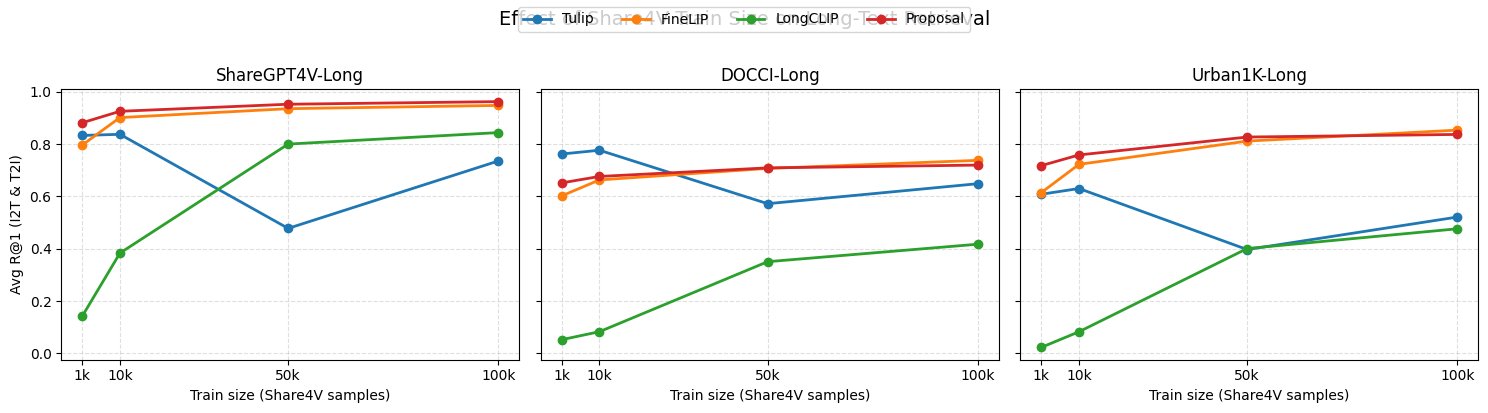

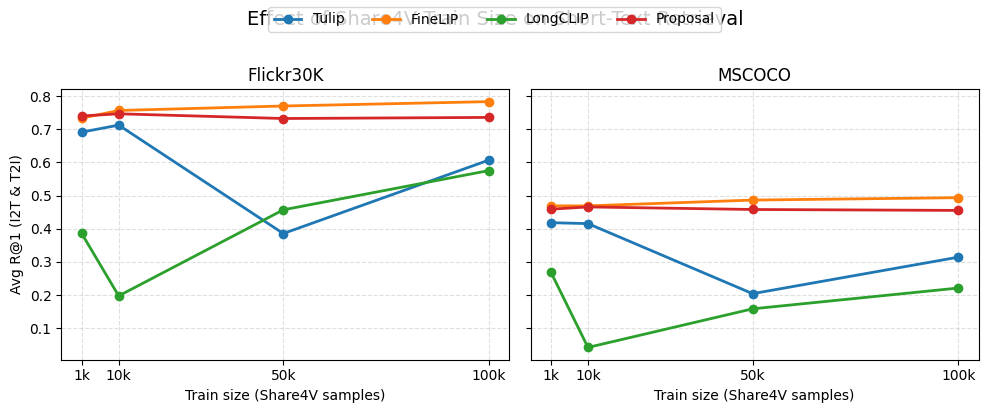

In [7]:
import matplotlib.pyplot as plt

# =========================
# Precomputed avg R@1 = (I2T_R1 + T2I_R1) / 2
# Order of sizes: [1k, 10k, 50k, 100k]
# =========================

sizes = [1, 10, 50, 100]
size_labels = ["1k", "10k", "50k", "100k"]

long_results = {
    "ShareGPT4V-Long": {
        "Tulip":    [0.8335, 0.8380, 0.4780, 0.7360],
        "FineLIP":  [0.7965, 0.9020, 0.9360, 0.9485],
        "LongCLIP": [0.1410, 0.3835, 0.8005, 0.8445],
        "Proposal": [0.8820, 0.9260, 0.9530, 0.9630],
    },
    "DOCCI-Long": {
        "Tulip":    [0.7625, 0.7770, 0.5725, 0.6490],
        "FineLIP":  [0.6023, 0.6634, 0.7075, 0.7383],
        "LongCLIP": [0.0521, 0.0828, 0.3506, 0.4175],
        "Proposal": [0.6520, 0.6767, 0.7095, 0.7202],
    },
    "Urban1K-Long": {
        "Tulip":    [0.6085, 0.6305, 0.3970, 0.5215],
        "FineLIP":  [0.6145, 0.7230, 0.8120, 0.8540],
        "LongCLIP": [0.0225, 0.0825, 0.4010, 0.4765],
        "Proposal": [0.7180, 0.7590, 0.8275, 0.8375],
    },
}

short_results = {
    "Flickr30K": {
        "Tulip":    [0.6912, 0.7124, 0.3855, 0.6072],
        "FineLIP":  [0.7333, 0.7565, 0.7700, 0.7832],
        "LongCLIP": [0.3860, 0.1975, 0.4570, 0.5755],
        "Proposal": [0.7399, 0.7465, 0.7323, 0.7356],
    },
    "MSCOCO": {
        "Tulip":    [0.4182, 0.4154, 0.2042, 0.3143],
        "FineLIP":  [0.4689, 0.4689, 0.4864, 0.4936],
        "LongCLIP": [0.2687, 0.0421, 0.1585, 0.2212],
        "Proposal": [0.4589, 0.4657, 0.4580, 0.4552],
    },
}


def plot_family(fig_title, results, n_cols, share_y=True):
    datasets = list(results.keys())
    fig, axes = plt.subplots(
        1, n_cols, figsize=(5 * n_cols, 4), sharey=share_y
    )

    if n_cols == 1:
        axes = [axes]

    for ax, ds_name in zip(axes, datasets):
        for model_name, vals in results[ds_name].items():
            ax.plot(sizes, vals, marker="o", linewidth=2, label=model_name)

        ax.set_title(ds_name)
        ax.set_xticks(sizes)
        ax.set_xticklabels(size_labels)
        ax.set_xlabel("Train size (Share4V samples)")
        ax.grid(True, linestyle="--", alpha=0.4)

    axes[0].set_ylabel("Avg R@1 (I2T & T2I)")
    # One shared legend per figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(labels))
    fig.suptitle(fig_title, y=1.02, fontsize=14)
    fig.tight_layout()


def main():
    # Figure 1: long-text datasets (ShareGPT4V, DOCCI, Urban1K)
    plot_family(
        "Effect of Share4V Train Size on Long-Text Retrieval",
        long_results,
        n_cols=3,
        share_y=True,
    )

    # Figure 2: short-text datasets (Flickr, COCO)
    plot_family(
        "Effect of Share4V Train Size on Short-Text Retrieval",
        short_results,
        n_cols=2,
        share_y=True,
    )

    plt.show()


if __name__ == "__main__":
    main()


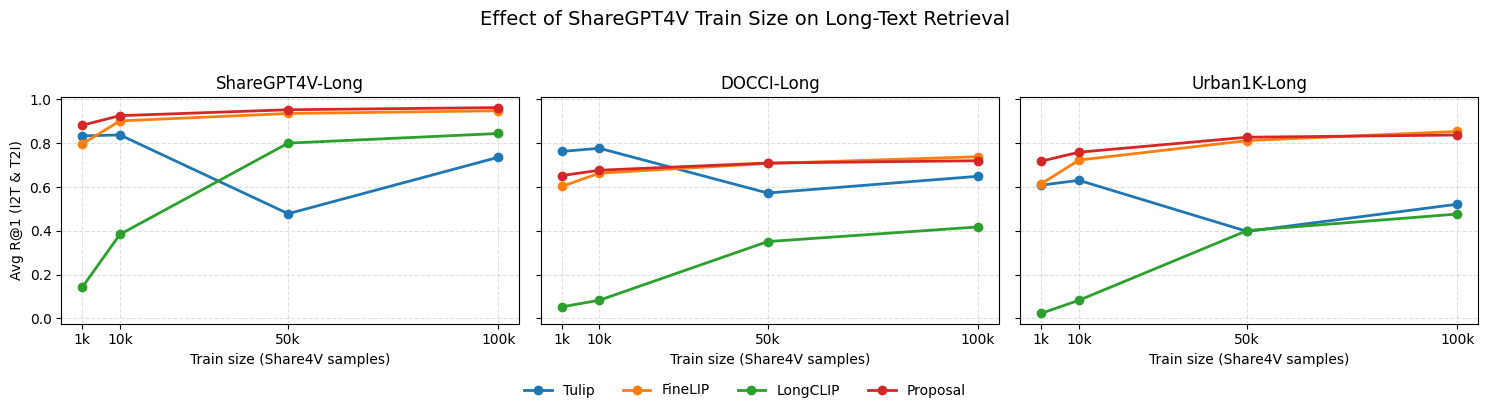

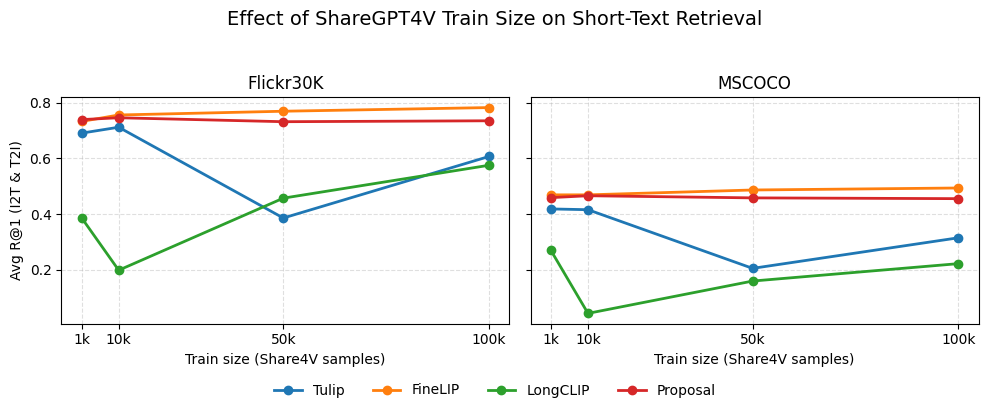

In [9]:
import matplotlib.pyplot as plt

# =========================
# Precomputed avg R@1 = (I2T_R1 + T2I_R1) / 2
# Order of sizes: [1k, 10k, 50k, 100k]
# =========================

sizes = [1, 10, 50, 100]
size_labels = ["1k", "10k", "50k", "100k"]

long_results = {
    "ShareGPT4V-Long": {
        "Tulip":    [0.8335, 0.8380, 0.4780, 0.7360],
        "FineLIP":  [0.7965, 0.9020, 0.9360, 0.9485],
        "LongCLIP": [0.1410, 0.3835, 0.8005, 0.8445],
        "Proposal": [0.8820, 0.9260, 0.9530, 0.9630],
    },
    "DOCCI-Long": {
        "Tulip":    [0.7625, 0.7770, 0.5725, 0.6490],
        "FineLIP":  [0.6023, 0.6634, 0.7075, 0.7383],
        "LongCLIP": [0.0521, 0.0828, 0.3506, 0.4175],
        "Proposal": [0.6520, 0.6767, 0.7095, 0.7202],
    },
    "Urban1K-Long": {
        "Tulip":    [0.6085, 0.6305, 0.3970, 0.5215],
        "FineLIP":  [0.6145, 0.7230, 0.8120, 0.8540],
        "LongCLIP": [0.0225, 0.0825, 0.4010, 0.4765],
        "Proposal": [0.7180, 0.7590, 0.8275, 0.8375],
    },
}

short_results = {
    "Flickr30K": {
        "Tulip":    [0.6912, 0.7124, 0.3855, 0.6072],
        "FineLIP":  [0.7333, 0.7565, 0.7700, 0.7832],
        "LongCLIP": [0.3860, 0.1975, 0.4570, 0.5755],
        "Proposal": [0.7399, 0.7465, 0.7323, 0.7356],
    },
    "MSCOCO": {
        "Tulip":    [0.4182, 0.4154, 0.2042, 0.3143],
        "FineLIP":  [0.4689, 0.4689, 0.4864, 0.4936],
        "LongCLIP": [0.2687, 0.0421, 0.1585, 0.2212],
        "Proposal": [0.4589, 0.4657, 0.4580, 0.4552],
    },
}


def plot_family(fig_title, results, n_cols, share_y=True):
    datasets = list(results.keys())
    fig, axes = plt.subplots(
        1, n_cols, figsize=(5 * n_cols, 4), sharey=share_y
    )

    if n_cols == 1:
        axes = [axes]

    for ax, ds_name in zip(axes, datasets):
        for model_name, vals in results[ds_name].items():
            ax.plot(sizes, vals, marker="o", linewidth=2, label=model_name)

        ax.set_title(ds_name)
        ax.set_xticks(sizes)
        ax.set_xticklabels(size_labels)
        ax.set_xlabel("Train size (Share4V samples)")
        ax.grid(True, linestyle="--", alpha=0.4)

    axes[0].set_ylabel("Avg R@1 (I2T & T2I)")

    # nice shared legend BELOW the plots
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=len(labels),
        frameon=False,
    )

    fig.suptitle(fig_title, y=0.98, fontsize=14)
    fig.tight_layout(rect=[0, 0.05, 1, 0.94])


def main():
    # Figure 1: long-text datasets (ShareGPT4V, DOCCI, Urban1K)
    plot_family(
        "Effect of ShareGPT4V Train Size on Long-Text Retrieval",
        long_results,
        n_cols=3,
        share_y=True,
    )

    # Figure 2: short-text datasets (Flickr, COCO)
    plot_family(
        "Effect of ShareGPT4V Train Size on Short-Text Retrieval",
        short_results,
        n_cols=2,
        share_y=True,
    )

    plt.show()


if __name__ == "__main__":
    main()


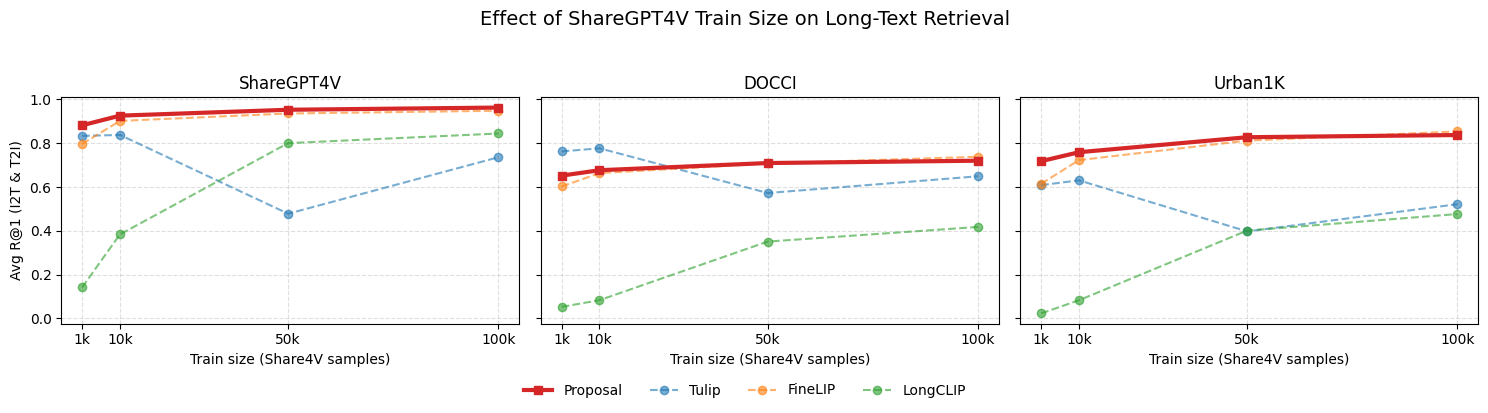

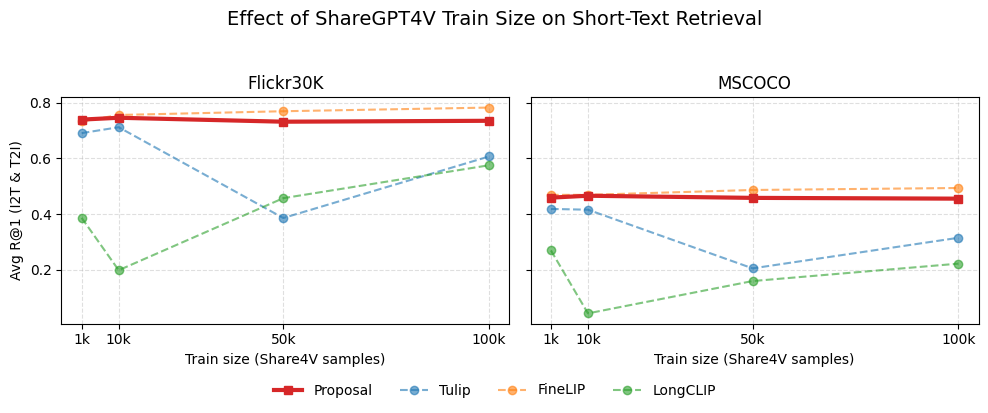

In [2]:
import matplotlib.pyplot as plt

# =========================
# Precomputed avg R@1 = (I2T_R1 + T2I_R1) / 2
# Order of sizes: [1k, 10k, 50k, 100k]
# =========================

sizes = [1, 10, 50, 100]
size_labels = ["1k", "10k", "50k", "100k"]

long_results = {
    "ShareGPT4V": {
        "Tulip":    [0.8335, 0.8380, 0.4780, 0.7360],
        "FineLIP":  [0.7965, 0.9020, 0.9360, 0.9485],
        "LongCLIP": [0.1410, 0.3835, 0.8005, 0.8445],
        "Proposal": [0.8820, 0.9260, 0.9530, 0.9630],
    },
    "DOCCI": {
        "Tulip":    [0.7625, 0.7770, 0.5725, 0.6490],
        "FineLIP":  [0.6023, 0.6634, 0.7075, 0.7383],
        "LongCLIP": [0.0521, 0.0828, 0.3506, 0.4175],
        "Proposal": [0.6520, 0.6767, 0.7095, 0.7202],
    },
    "Urban1K": {
        "Tulip":    [0.6085, 0.6305, 0.3970, 0.5215],
        "FineLIP":  [0.6145, 0.7230, 0.8120, 0.8540],
        "LongCLIP": [0.0225, 0.0825, 0.4010, 0.4765],
        "Proposal": [0.7180, 0.7590, 0.8275, 0.8375],
    },
}

short_results = {
    "Flickr30K": {
        "Tulip":    [0.6912, 0.7124, 0.3855, 0.6072],
        "FineLIP":  [0.7333, 0.7565, 0.7700, 0.7832],
        "LongCLIP": [0.3860, 0.1975, 0.4570, 0.5755],
        "Proposal": [0.7399, 0.7465, 0.7323, 0.7356],
    },
    "MSCOCO": {
        "Tulip":    [0.4182, 0.4154, 0.2042, 0.3143],
        "FineLIP":  [0.4689, 0.4689, 0.4864, 0.4936],
        "LongCLIP": [0.2687, 0.0421, 0.1585, 0.2212],
        "Proposal": [0.4589, 0.4657, 0.4580, 0.4552],
    },
}


def plot_family(fig_title, results, n_cols, share_y=True):
    highlight = "Proposal"

    datasets = list(results.keys())
    fig, axes = plt.subplots(
        1, n_cols, figsize=(5 * n_cols, 4), sharey=share_y
    )

    if n_cols == 1:
        axes = [axes]

    for ax, ds_name in zip(axes, datasets):
        for model_name, vals in results[ds_name].items():
            if model_name == highlight:
                # bold, solid line for Proposal
                ax.plot(
                    sizes,
                    vals,
                    marker="s",
                    linewidth=3,
                    linestyle="-",
                    label=model_name,
                )
            else:
                # thinner, lighter, dashed lines for others
                ax.plot(
                    sizes,
                    vals,
                    marker="o",
                    linewidth=1.5,
                    linestyle="--",
                    alpha=0.6,
                    label=model_name,
                )

        ax.set_title(ds_name)
        ax.set_xticks(sizes)
        ax.set_xticklabels(size_labels)
        ax.set_xlabel("Train size (Share4V samples)")
        ax.grid(True, linestyle="--", alpha=0.4)

    axes[0].set_ylabel("Avg R@1 (I2T & T2I)")

    # shared legend below plots, with Proposal first
    handles, labels = axes[0].get_legend_handles_labels()
    if highlight in labels:
        idx = labels.index(highlight)
        handles = [handles[idx]] + handles[:idx] + handles[idx + 1 :]
        labels = [labels[idx]] + labels[:idx] + labels[idx + 1 :]

    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
        ncol=len(labels),
        frameon=False,
    )

    fig.suptitle(fig_title, y=0.98, fontsize=14)
    fig.tight_layout(rect=[0, 0.05, 1, 0.94])


def main():
    # Figure 1: long-text datasets (ShareGPT4V, DOCCI, Urban1K)
    plot_family(
        "Effect of ShareGPT4V Train Size on Long-Text Retrieval",
        long_results,
        n_cols=3,
        share_y=True,
    )

    # Figure 2: short-text datasets (Flickr, COCO)
    plot_family(
        "Effect of ShareGPT4V Train Size on Short-Text Retrieval",
        short_results,
        n_cols=2,
        share_y=True,
    )

    plt.show()


if __name__ == "__main__":
    main()


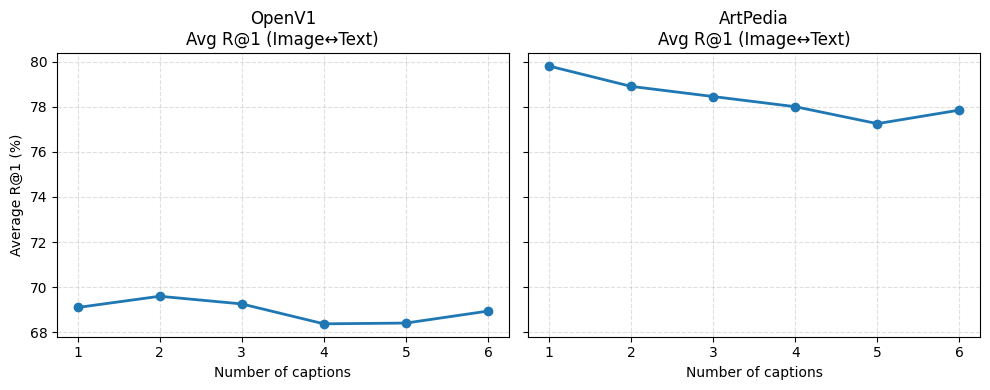

In [1]:
import matplotlib.pyplot as plt

def main():
    # Number of captions (sub-sentences)
    num_caps = [1, 2, 3, 4, 5, 6]

    # ----------------------------
    # OpenV1 data (R@1, in %)
    # ----------------------------
    openv1_t2i_r1 = [
        67.6044,  # 1 sentence
        68.3303,  # 2
        67.8766,  # 3
        66.7196,  # 4
        67.2187,  # 5
        67.7858,  # 6
    ]

    openv1_i2t_r1 = [
        70.5762,  # 1 sentence
        70.8485,  # 2
        70.6216,  # 3
        70.0091,  # 4
        69.5780,  # 5
        70.0771,  # 6
    ]

    openv1_avg_r1 = [
        (t2i + i2t) / 2.0
        for t2i, i2t in zip(openv1_t2i_r1, openv1_i2t_r1)
    ]

    # ----------------------------
    # ArtPedia data (R@1, in %)
    # ----------------------------
    artpedia_t2i_r1 = [
        78.3132,  # 1 sentence
        78.3132,  # 2
        77.4096,  # 3
        77.4096,  # 4
        75.6024,  # 5
        76.2048,  # 6
    ]

    artpedia_i2t_r1 = [
        81.3253,  # 1 sentence
        79.5181,  # 2
        79.5181,  # 3
        78.6145,  # 4
        78.9157,  # 5
        79.5181,  # 6
    ]

    artpedia_avg_r1 = [
        (t2i + i2t) / 2.0
        for t2i, i2t in zip(artpedia_t2i_r1, artpedia_i2t_r1)
    ]

    # ----------------------------
    # Plotting
    # ----------------------------
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    # Left: OpenV1
    ax = axes[0]
    ax.plot(num_caps, openv1_avg_r1, marker="o", linewidth=2)
    ax.set_title("OpenV1\nAvg R@1 (Image↔Text)")
    ax.set_xlabel("Number of captions")
    ax.set_ylabel("Average R@1 (%)")
    ax.set_xticks(num_caps)
    ax.grid(True, linestyle="--", alpha=0.4)

    # Right: ArtPedia
    ax = axes[1]
    ax.plot(num_caps, artpedia_avg_r1, marker="o", linewidth=2)
    ax.set_title("ArtPedia\nAvg R@1 (Image↔Text)")
    ax.set_xlabel("Number of captions")
    ax.set_xticks(num_caps)
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


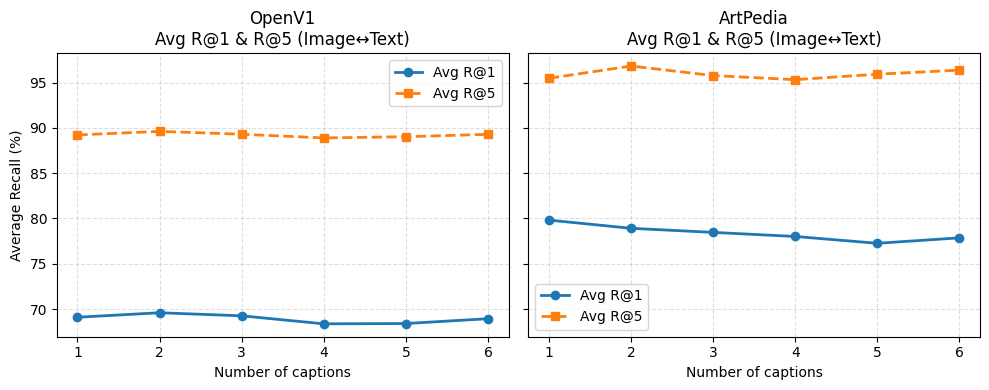

In [2]:
import matplotlib.pyplot as plt

def main():
    # Number of captions (sub-sentences)
    num_caps = [1, 2, 3, 4, 5, 6]

    # ----------------------------
    # OpenV1 data (R@1 and R@5, in %)
    # ----------------------------
    openv1_t2i_r1 = [
        67.6044,  # 1 sentence
        68.3303,  # 2
        67.8766,  # 3
        66.7196,  # 4
        67.2187,  # 5
        67.7858,  # 6
    ]
    openv1_i2t_r1 = [
        70.5762,  # 1 sentence
        70.8485,  # 2
        70.6216,  # 3
        70.0091,  # 4
        69.5780,  # 5
        70.0771,  # 6
    ]

    openv1_t2i_r5 = [
        88.6116,  # 1 sentence
        89.1334,  # 2
        88.7704,  # 3
        88.2940,  # 4
        88.5436,  # 5
        88.9519,  # 6
    ]
    openv1_i2t_r5 = [
        89.8367,  # 1 sentence
        90.1089,  # 2
        89.8367,  # 3
        89.4964,  # 4
        89.5191,  # 5
        89.6325,  # 6
    ]

    openv1_avg_r1 = [(t2i + i2t) / 2.0 for t2i, i2t in zip(openv1_t2i_r1, openv1_i2t_r1)]
    openv1_avg_r5 = [(t2i + i2t) / 2.0 for t2i, i2t in zip(openv1_t2i_r5, openv1_i2t_r5)]

    # ----------------------------
    # ArtPedia data (R@1 and R@5, in %)
    # ----------------------------
    artpedia_t2i_r1 = [
        78.3132,  # 1 sentence
        78.3132,  # 2
        77.4096,  # 3
        77.4096,  # 4
        75.6024,  # 5
        76.2048,  # 6
    ]
    artpedia_i2t_r1 = [
        81.3253,  # 1 sentence
        79.5181,  # 2
        79.5181,  # 3
        78.6145,  # 4
        78.9157,  # 5
        79.5181,  # 6
    ]

    artpedia_t2i_r5 = [
        94.8795,  # 1 sentence
        96.3855,  # 2
        94.8795,  # 3
        95.4819,  # 4
        96.0843,  # 5
        96.0843,  # 6
    ]
    artpedia_i2t_r5 = [
        96.0843,  # 1 sentence
        97.2892,  # 2
        96.6867,  # 3
        95.1807,  # 4
        95.7831,  # 5
        96.6867,  # 6
    ]

    artpedia_avg_r1 = [(t2i + i2t) / 2.0 for t2i, i2t in zip(artpedia_t2i_r1, artpedia_i2t_r1)]
    artpedia_avg_r5 = [(t2i + i2t) / 2.0 for t2i, i2t in zip(artpedia_t2i_r5, artpedia_i2t_r5)]

    # ----------------------------
    # Plotting
    # ----------------------------
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    # Left: OpenV1
    ax = axes[0]
    ax.plot(num_caps, openv1_avg_r1, marker="o", linewidth=2, label="Avg R@1")
    ax.plot(num_caps, openv1_avg_r5, marker="s", linewidth=2, linestyle="--", label="Avg R@5")
    ax.set_title("OpenV1\nAvg R@1 & R@5 (Image↔Text)")
    ax.set_xlabel("Number of captions")
    ax.set_ylabel("Average Recall (%)")
    ax.set_xticks(num_caps)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

    # Right: ArtPedia
    ax = axes[1]
    ax.plot(num_caps, artpedia_avg_r1, marker="o", linewidth=2, label="Avg R@1")
    ax.plot(num_caps, artpedia_avg_r5, marker="s", linewidth=2, linestyle="--", label="Avg R@5")
    ax.set_title("ArtPedia\nAvg R@1 & R@5 (Image↔Text)")
    ax.set_xlabel("Number of captions")
    ax.set_xticks(num_caps)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


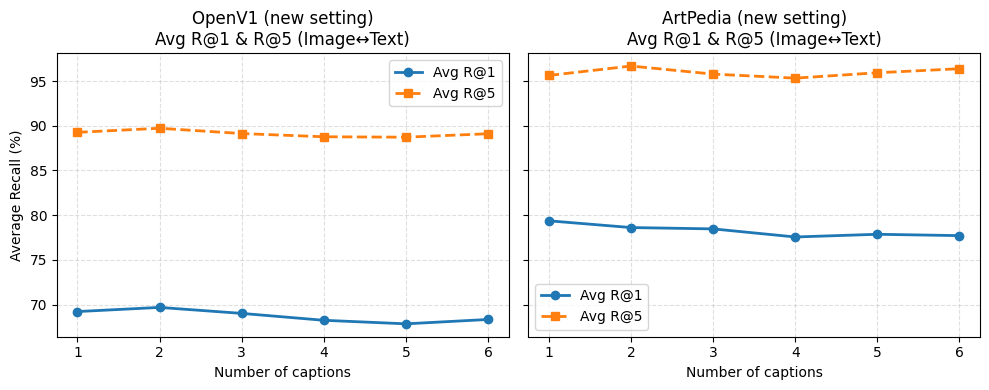

In [1]:
import matplotlib.pyplot as plt

def main():
    # Number of captions (sub-sentences)
    num_caps = [1, 2, 3, 4, 5, 6]

    # ----------------------------
    # OpenV1 data (R@1 and R@5, in %)
    # ----------------------------
    openv1_t2i_r1 = [
        67.5817,  # 1 sentence
        68.4211,  # 2
        67.5817,  # 3
        66.7423,  # 4
        66.2205,  # 5
        67.2414,  # 6
    ]
    openv1_i2t_r1 = [
        70.8485,  # 1 sentence
        70.9392,  # 2
        70.4401,  # 3
        69.7368,  # 4
        69.4646,  # 5
        69.4192,  # 6
    ]

    openv1_t2i_r5 = [
        88.6343,  # 1 sentence
        89.2468,  # 2
        88.7024,  # 3
        88.2033,  # 4
        88.1125,  # 5
        88.7250,  # 6
    ]
    openv1_i2t_r5 = [
        89.9047,  # 1 sentence
        90.1996,  # 2
        89.5644,  # 3
        89.3376,  # 4
        89.3376,  # 5
        89.4964,  # 6
    ]

    openv1_avg_r1 = [(t2i + i2t) / 2.0 for t2i, i2t in zip(openv1_t2i_r1, openv1_i2t_r1)]
    openv1_avg_r5 = [(t2i + i2t) / 2.0 for t2i, i2t in zip(openv1_t2i_r5, openv1_i2t_r5)]

    # ----------------------------
    # ArtPedia data (R@1 and R@5, in %)
    # ----------------------------
    artpedia_t2i_r1 = [
        78.0120,  # 1 sentence
        78.0120,  # 2
        77.4096,  # 3
        77.1084,  # 4
        75.9036,  # 5
        76.8072,  # 6
    ]
    artpedia_i2t_r1 = [
        80.7229,  # 1 sentence
        79.2169,  # 2
        79.5181,  # 3
        78.0120,  # 4
        79.8193,  # 5
        78.6145,  # 6
    ]

    artpedia_t2i_r5 = [
        94.8795,  # 1 sentence
        96.3855,  # 2
        94.8795,  # 3
        95.4819,  # 4
        95.7831,  # 5
        96.0843,  # 6
    ]
    artpedia_i2t_r5 = [
        96.3855,  # 1 sentence
        96.9880,  # 2
        96.6867,  # 3
        95.1807,  # 4
        96.0843,  # 5
        96.6867,  # 6
    ]

    artpedia_avg_r1 = [(t2i + i2t) / 2.0 for t2i, i2t in zip(artpedia_t2i_r1, artpedia_i2t_r1)]
    artpedia_avg_r5 = [(t2i + i2t) / 2.0 for t2i, i2t in zip(artpedia_t2i_r5, artpedia_i2t_r5)]

    # ----------------------------
    # Plotting
    # ----------------------------
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    # Left: OpenV1
    ax = axes[0]
    ax.plot(num_caps, openv1_avg_r1, marker="o", linewidth=2, label="Avg R@1")
    ax.plot(num_caps, openv1_avg_r5, marker="s", linewidth=2, linestyle="--", label="Avg R@5")
    ax.set_title("OpenV1 (new setting)\nAvg R@1 & R@5 (Image↔Text)")
    ax.set_xlabel("Number of captions")
    ax.set_ylabel("Average Recall (%)")
    ax.set_xticks(num_caps)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

    # Right: ArtPedia
    ax = axes[1]
    ax.plot(num_caps, artpedia_avg_r1, marker="o", linewidth=2, label="Avg R@1")
    ax.plot(num_caps, artpedia_avg_r5, marker="s", linewidth=2, linestyle="--", label="Avg R@5")
    ax.set_title("ArtPedia (new setting)\nAvg R@1 & R@5 (Image↔Text)")
    ax.set_xlabel("Number of captions")
    ax.set_xticks(num_caps)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()


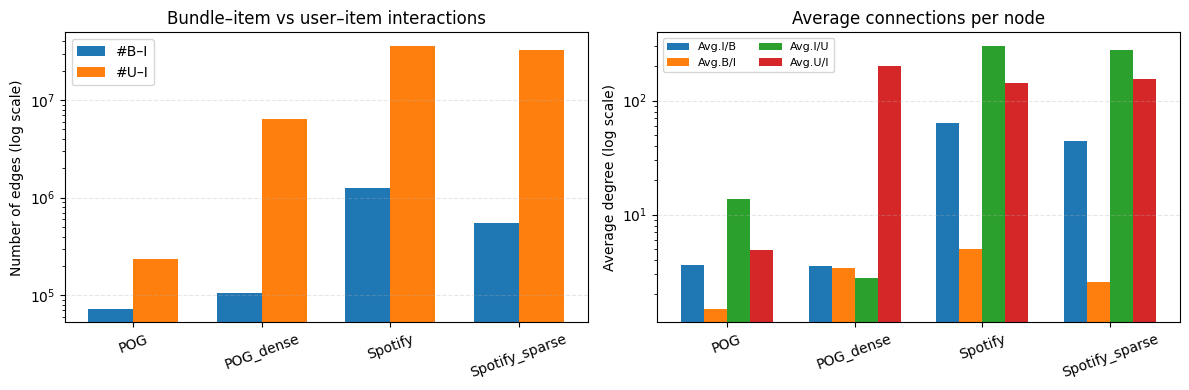

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# =======================
# Data từ Table 1
# =======================
datasets = ["POG", "POG_dense", "Spotify", "Spotify_sparse"]

U  = [17449,   2311431, 118994, 118899]
I  = [48676,     31217, 254155, 213325]
B  = [20000,     29686, 20000,  12486]
BI = [72224,    105775, 1268716, 549900]    # #B-I
UI = [237519,  6345137, 36244806, 32890315] # #U-I

avg_I_B = [3.61,  3.56, 63.44, 44.04]   # #items per bundle
avg_B_I = [1.48,  3.39,  4.99,  2.58]   # #bundles per item
avg_I_U = [13.61, 2.75, 304.59, 276.62] # #items per user
avg_U_I = [4.88, 203.26, 142.61, 154.18]# #users per item

# ============== Figure ==============
x = np.arange(len(datasets))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ---- (a) Edge counts: B-I vs U-I (log scale) ----
width = 0.35
ax = axes[0]
ax.bar(x - width/2, BI, width, label="#B–I")
ax.bar(x + width/2, UI, width, label="#U–I")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=20)
ax.set_ylabel("Number of edges (log scale)")
ax.set_title("Bundle–item vs user–item interactions")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

# ---- (b) Average degrees (density view) ----
width = 0.18
ax = axes[1]
ax.bar(x - 1.5*width, avg_I_B, width, label="Avg.I/B")
ax.bar(x - 0.5*width, avg_B_I, width, label="Avg.B/I")
ax.bar(x + 0.5*width, avg_I_U, width, label="Avg.I/U")
ax.bar(x + 1.5*width, avg_U_I, width, label="Avg.U/I")

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=20)
ax.set_ylabel("Average degree (log scale)")
ax.set_title("Average connections per node")
ax.legend(ncol=2, fontsize=8)
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


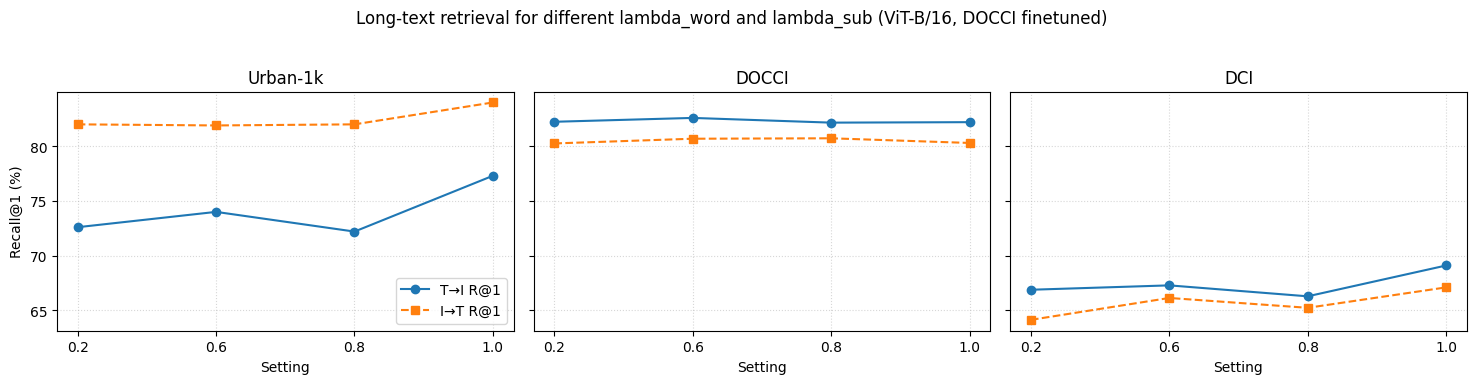

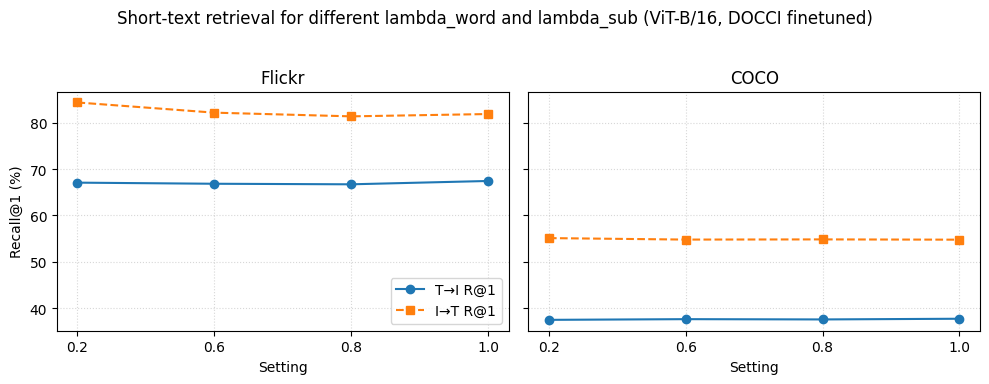

In [2]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt

# Các setting tương ứng với:
# b16 docci 02 02, 06 06, 08 08, 1 1
scale_labels = ["0.2", "0.6", "0.8", "1.0"]
x = list(range(len(scale_labels)))

# =========================
# R@1 cho long-text datasets
# =========================
data_long = {
    "Urban-1k": {
        # b16 docci 02, 06, 08, 1
        "T2I": [72.6000, 74.0000, 72.2000, 77.3],
        "I2T": [82.0000, 81.9000, 82.0000, 84.0],
    },
    "DOCCI": {
        "T2I": [82.2353, 82.5882, 82.1569, 82.2],
        "I2T": [80.2549, 80.6863, 80.7255, 80.3],
    },
    "DCI": {
        "T2I": [66.8834, 67.2836, 66.2831, 69.1],
        "I2T": [64.1321, 66.1331, 65.2326, 67.1],
    },
}

# =========================
# R@1 cho short-text datasets
# =========================
data_short = {
    "Flickr": {
        "T2I": [67.08, 66.84, 66.72, 67.44],
        "I2T": [84.40, 82.20, 81.40, 81.90],
    },
    "COCO": {
        "T2I": [37.44, 37.59, 37.53, 37.68],
        "I2T": [55.10, 54.78, 54.82, 54.76],
    },
}

# =========================
# Figure 1: 3 line chart cho Urban-1k, DOCCI, DCI
# =========================
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, (dataset_name, vals) in zip(axes1, data_long.items()):
    ax.plot(x, vals["T2I"], marker="o", linestyle="-", label="T→I R@1")
    ax.plot(x, vals["I2T"], marker="s", linestyle="--", label="I→T R@1")

    ax.set_title(dataset_name)
    ax.set_xticks(x)
    ax.set_xticklabels(scale_labels)
    ax.set_xlabel("Setting")
    ax.grid(True, linestyle=":", alpha=0.5)

axes1[0].set_ylabel("Recall@1 (%)")
axes1[0].legend(loc="lower right")

fig1.suptitle("Long-text retrieval for different lambda_word and lambda_sub (ViT-B/16, DOCCI finetuned)")
fig1.tight_layout(rect=[0, 0.03, 1, 0.95])

# =========================
# Figure 2: 2 line chart cho Flickr, COCO
# =========================
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for ax, (dataset_name, vals) in zip(axes2, data_short.items()):
    ax.plot(x, vals["T2I"], marker="o", linestyle="-", label="T→I R@1")
    ax.plot(x, vals["I2T"], marker="s", linestyle="--", label="I→T R@1")

    ax.set_title(dataset_name)
    ax.set_xticks(x)
    ax.set_xticklabels(scale_labels)
    ax.set_xlabel("Setting")
    ax.grid(True, linestyle=":", alpha=0.5)

axes2[0].set_ylabel("Recall@1 (%)")
axes2[0].legend(loc="lower right")

fig2.suptitle("Short-text retrieval for different lambda_word and lambda_sub (ViT-B/16, DOCCI finetuned)")
fig2.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()


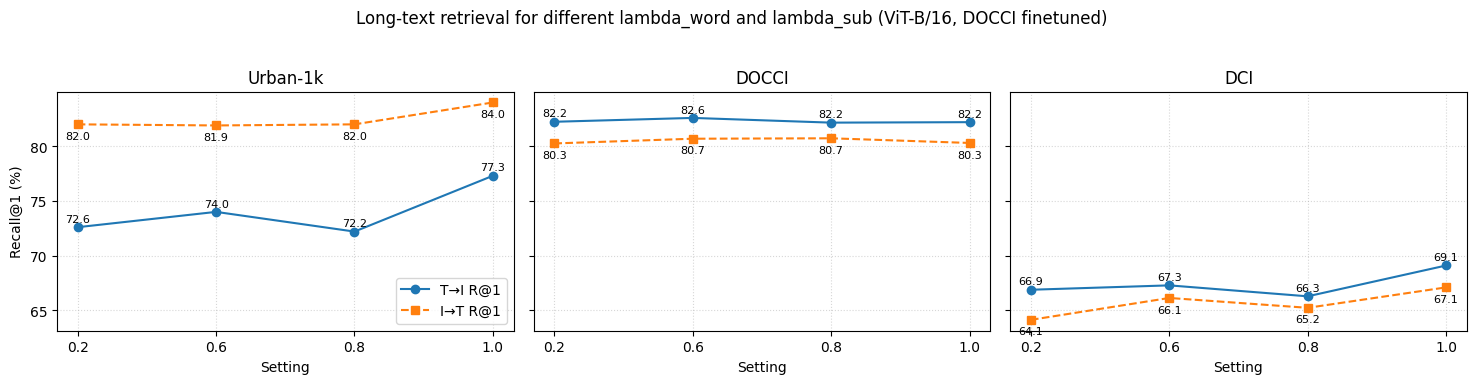

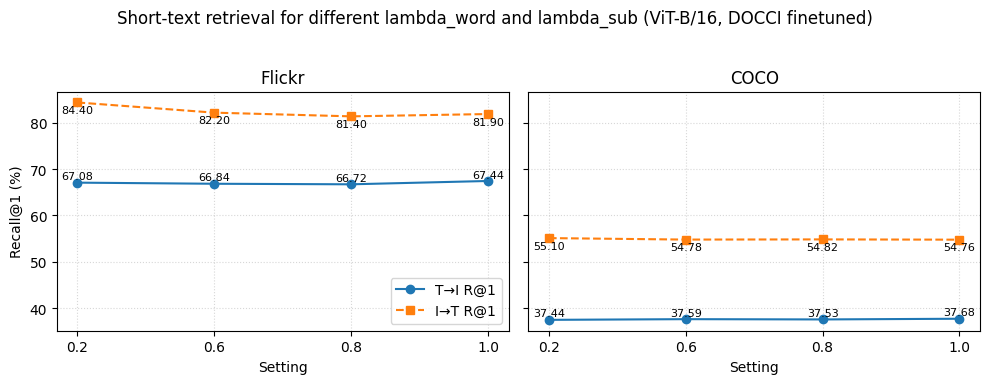

In [1]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt

# Các setting tương ứng với:
# b16 docci 02 02, 06 06, 08 08, 1 1
scale_labels = ["0.2", "0.6", "0.8", "1.0"]
x = list(range(len(scale_labels)))

# =========================
# R@1 cho long-text datasets
# =========================
data_long = {
    "Urban-1k": {
        # b16 docci 02, 06, 08, 1
        "T2I": [72.6000, 74.0000, 72.2000, 77.3],
        "I2T": [82.0000, 81.9000, 82.0000, 84.0],
    },
    "DOCCI": {
        "T2I": [82.2353, 82.5882, 82.1569, 82.2],
        "I2T": [80.2549, 80.6863, 80.7255, 80.3],
    },
    "DCI": {
        "T2I": [66.8834, 67.2836, 66.2831, 69.1],
        "I2T": [64.1321, 66.1331, 65.2326, 67.1],
    },
}

# =========================
# R@1 cho short-text datasets
# =========================
data_short = {
    "Flickr": {
        "T2I": [67.08, 66.84, 66.72, 67.44],
        "I2T": [84.40, 82.20, 81.40, 81.90],
    },
    "COCO": {
        "T2I": [37.44, 37.59, 37.53, 37.68],
        "I2T": [55.10, 54.78, 54.82, 54.76],
    },
}

# =========================
# Figure 1: 3 line chart cho Urban-1k, DOCCI, DCI
# =========================
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, (dataset_name, vals) in zip(axes1, data_long.items()):
    # Vẽ đường
    ax.plot(x, vals["T2I"], marker="o", linestyle="-", label="T→I R@1")
    ax.plot(x, vals["I2T"], marker="s", linestyle="--", label="I→T R@1")

    # Thêm số cho từng điểm (T2I)
    for i, y in enumerate(vals["T2I"]):
        ax.text(i, y + 0.3, f"{y:.1f}", ha="center", va="bottom", fontsize=8)

    # Thêm số cho từng điểm (I2T) – đẩy xuống một chút để đỡ đè
    for i, y in enumerate(vals["I2T"]):
        ax.text(i, y - 0.6, f"{y:.1f}", ha="center", va="top", fontsize=8)

    ax.set_title(dataset_name)
    ax.set_xticks(x)
    ax.set_xticklabels(scale_labels)
    ax.set_xlabel("Setting")
    ax.grid(True, linestyle=":", alpha=0.5)

axes1[0].set_ylabel("Recall@1 (%)")
axes1[0].legend(loc="lower right")

fig1.suptitle("Long-text retrieval for different lambda_word and lambda_sub (ViT-B/16, DOCCI finetuned)")
fig1.tight_layout(rect=[0, 0.03, 1, 0.95])

# =========================
# Figure 2: 2 line chart cho Flickr, COCO
# =========================
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

for ax, (dataset_name, vals) in zip(axes2, data_short.items()):
    ax.plot(x, vals["T2I"], marker="o", linestyle="-", label="T→I R@1")
    ax.plot(x, vals["I2T"], marker="s", linestyle="--", label="I→T R@1")

    # Thêm số cho từng điểm (T2I)
    for i, y in enumerate(vals["T2I"]):
        ax.text(i, y + 0.3, f"{y:.2f}", ha="center", va="bottom", fontsize=8)

    # Thêm số cho từng điểm (I2T)
    for i, y in enumerate(vals["I2T"]):
        ax.text(i, y - 0.6, f"{y:.2f}", ha="center", va="top", fontsize=8)

    ax.set_title(dataset_name)
    ax.set_xticks(x)
    ax.set_xticklabels(scale_labels)
    ax.set_xlabel("Setting")
    ax.grid(True, linestyle=":", alpha=0.5)

axes2[0].set_ylabel("Recall@1 (%)")
axes2[0].legend(loc="lower right")

fig2.suptitle("Short-text retrieval for different lambda_word and lambda_sub (ViT-B/16, DOCCI finetuned)")
fig2.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()
